# Bước 3: Tạo Knowledge Graph — PhoBERT NER + Rule-based Relation Extraction

**Model:** `phobert-ner-final` — fine-tuned từ bước 2 trên 13,900 bài báo doanh nghiệp Việt Nam

**Input:** `raw_data_2_pre.csv` (text gốc) + `phobert-ner-final/` (model đã train)

**Pipeline:**
```
raw_data_2_pre.csv
        │
        ▼
[1] Text Normalization & Sentence Splitting
        │
        ▼
[2] PhoBERT NER Inference (GPU batch)
    phobert-ner-final → PERSON, ORG, LOC,
    PRODUCT, EVENT, INDUSTRY, MONEY, DATE, PERCENT
        │
        ▼
[3] Entity Normalization
    Unicode NFC · alias resolution · length filter
        │
        ▼
[4] Rule-based Relation Extraction
    11 Vietnamese syntax patterns
    + co-occurrence fallback
        │
        ▼
[5] Triple Filtering & Deduplication
    confidence · noise · frequency boost
        │
        ▼
[6] Knowledge Graph Build → NetworkX MultiDiGraph
        │
        ▼
[7] Export: triples.csv · triples.json · .graphml · .gexf · interactive HTML
```

**So với cách đọc CSV (bước 3 cũ):**

| | Đọc `ner_labeled_data.csv` | PhoBERT trực tiếp (notebook này) |
|---|---|---|
| Chất lượng entity | Electra + rule (domain chung) | PhoBERT fine-tuned (domain doanh nghiệp) |
| Dùng cho bài mới | ❌ | ✅ |
| Tốc độ | Rất nhanh | Cần GPU (~30–60 phút cho 13K bài) |

## 0. Cài đặt thư viện

In [1]:
import subprocess, sys

pkgs = [
    'transformers>=4.40.0',
    'torch',
    'networkx>=3.2',
    'pandas>=2.0',
    'tqdm',
    'matplotlib',
    'pyvis',
    'lxml',
    'unidecode',
]
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs, check=True)
print('Done.')

Done.


## 1. Import & Config

In [2]:
import re
import json
import time
import warnings
import unicodedata
from pathlib import Path
from typing import List, Tuple, Dict, Optional, Set
from collections import defaultdict, Counter
from dataclasses import dataclass, field

import torch
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    pipeline as hf_pipeline,
)

warnings.filterwarnings('ignore')

# ── GPU check ────────────────────────────────────────────────
DEVICE = 0 if torch.cuda.is_available() else -1
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print(f'GPU  : {torch.cuda.get_device_name(0)}')
    print(f'VRAM : {gpu.total_memory / 1024**3:.1f} GB')
else:
    print('CUDA không khả dụng — inference sẽ chạy trên CPU (chậm hơn ~10x)')

# ── Config ────────────────────────────────────────────────────
CFG = {
    # Input
    'input_csv'        : 'CSV/raw_data_2_pre.csv',
    'model_dir'        : 'phobert-ner-final',   # output từ bước 2

    # Inference
    'batch_size'       : 32,      # giảm xuống 16 nếu OOM
    'max_length'       : 256,     # PhoBERT max = 256
    'max_sent_chars'   : 600,     # câu dài hơn → tách chunk
    'min_ner_score'    : 0.70,    # loại entity có confidence < ngưỡng

    # Triple filtering
    'min_confidence'   : 0.50,
    'max_entity_len'   : 80,
    'min_entity_len'   : 2,
    'min_triple_freq'  : 1,

    # Graph viz
    'top_k_viz'        : 100,
    'top_k_labels'     : 20,

    # Output
    'output_dir'       : 'knowledge_graph_output',

    # Debug: đặt số nhỏ để test nhanh, None = toàn bộ
    'max_rows'         : None,
}

OUT = Path(CFG['output_dir'])
OUT.mkdir(exist_ok=True)

print('\nConfig:')
for k, v in CFG.items():
    print(f'  {k:20s}: {v}')

c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA không khả dụng — inference sẽ chạy trên CPU (chậm hơn ~10x)

Config:
  input_csv           : CSV/raw_data_2_pre.csv
  model_dir           : phobert-ner-final
  batch_size          : 32
  max_length          : 256
  max_sent_chars      : 600
  min_ner_score       : 0.7
  min_confidence      : 0.5
  max_entity_len      : 80
  min_entity_len      : 2
  min_triple_freq     : 1
  top_k_viz           : 100
  top_k_labels        : 20
  output_dir          : knowledge_graph_output
  max_rows            : None


## 2. Load PhoBERT NER Model

Load model từ `phobert-ner-final/` — đã lưu đầy đủ `config.json`, `label2id.json`, `tokenizer_config.json`.

In [3]:
MODEL_DIR = Path(CFG['model_dir'])
assert MODEL_DIR.exists(), (
    f"Không tìm thấy '{MODEL_DIR}'. "
    "Chạy training_phobert_ner.ipynb trước để tạo model."
)

# ── Load label mapping từ file (tránh hard-code) ─────────────
with open(MODEL_DIR / 'label2id.json', encoding='utf-8') as f:
    label2id: Dict[str, int] = json.load(f)
with open(MODEL_DIR / 'id2label.json', encoding='utf-8') as f:
    id2label: Dict[int, str] = {int(k): v for k, v in json.load(f).items()}

print(f'Model dir  : {MODEL_DIR.resolve()}')
print(f'Num labels : {len(label2id)}')
print(f'Labels     : {sorted(label2id.keys())}')

# ── Load tokenizer & model ────────────────────────────────────
print('\nLoading tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(str(MODEL_DIR))
print(f'  Vocab size   : {tokenizer.vocab_size:,}')
print(f'  Fast         : {tokenizer.is_fast}')

print('Loading model...')
t0 = time.time()
ner_model = AutoModelForTokenClassification.from_pretrained(str(MODEL_DIR))
ner_model.eval()
if DEVICE >= 0:
    ner_model = ner_model.cuda()
    vram = torch.cuda.memory_allocated(0) / 1024**2
    print(f'  VRAM used    : {vram:.0f} MB')
print(f'  Load time    : {time.time()-t0:.1f}s')

# ── HuggingFace pipeline (batch inference) ───────────────────
# aggregation_strategy='simple' → gộp subword tokens thành word-level entities
ner_pipe = hf_pipeline(
    'ner',
    model       = ner_model,
    tokenizer   = tokenizer,
    aggregation_strategy = 'simple',
    device      = DEVICE,
    batch_size  = CFG['batch_size'],
)

# ── Sanity check ──────────────────────────────────────────────
test_sents = [
    'BIDV và VPBank ký kết hợp tác chiến lược tại Hà Nội.',
    'Apple ra mắt iPhone 17 Pro Max tại WWDC 2025 với giá 1.199 USD.',
    'Ông Trương Gia Bình - Chủ tịch FPT phát biểu tại sự kiện.',
]
print('\nSanity check:')
for sent in test_sents:
    ents = ner_pipe(sent)
    print(f'  Input: {sent[:60]}...')
    for e in ents:
        if e['score'] >= CFG['min_ner_score']:
            print(f'    [{e["entity_group"]:12s}] ({e["score"]:.3f}) "{e["word"]}"')

Model dir  : D:\KLTN\extraction-system\phobert-ner-final
Num labels : 19
Labels     : ['B-DATE', 'B-EVENT', 'B-INDUSTRY', 'B-LOCATION', 'B-MONEY', 'B-ORGANIZATION', 'B-PERCENT', 'B-PERSON', 'B-PRODUCT', 'I-DATE', 'I-EVENT', 'I-INDUSTRY', 'I-LOCATION', 'I-MONEY', 'I-ORGANIZATION', 'I-PERCENT', 'I-PERSON', 'I-PRODUCT', 'O']

Loading tokenizer...
  Vocab size   : 64,000
  Fast         : False
Loading model...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8081.98it/s]

  Load time    : 0.2s

Sanity check:


  Input: BIDV và VPBank ký kết hợp tác chiến lược tại Hà Nội....
    [ORGANIZATION] (1.000) "BIDV"
    [ORGANIZATION] (1.000) "VPBank"
    [LOCATION    ] (1.000) "Hà"
  Input: Apple ra mắt iPhone 17 Pro Max tại WWDC 2025 với giá 1.199 U...
    [ORGANIZATION] (1.000) "Apple"
    [PRODUCT     ] (1.000) "iPhone 17 Pro Max"
    [EVENT       ] (1.000) "WWDC 2025"
  Input: Ông Trương Gia Bình - Chủ tịch FPT phát biểu tại sự kiện....
    [PERSON      ] (1.000) "Trương Gia Bình"
    [ORGANIZATION] (1.000) "FPT"


## 3. Load Dataset & Text Normalization

In [4]:
# ── Normalize map (từ labeling.ipynb, giữ nhất quán) ─────────
_NORM_MAP = {
    '\u00a0':' ','\u200b':'','\u200c':'','\u200d':'','\ufeff':'',
    '\u2013':'-','\u2014':'-','\u2018':"'",'\u2019':"'",
    '\u201c':'"','\u201d':'"','\u2026':'...','\u202f':' ',
}
_NORM_RE    = re.compile('|'.join(re.escape(k) for k in _NORM_MAP))
_MULTI_SPC  = re.compile(r'[ \t]{2,}')

def normalize_text(text: str) -> str:
    if not isinstance(text, str): return ''
    text = unicodedata.normalize('NFC', text)
    text = _NORM_RE.sub(lambda m: _NORM_MAP[m.group()], text)
    text = _MULTI_SPC.sub(' ', text)
    return text.strip()


def split_sentences(text: str, max_chars: int = 600) -> List[str]:
    """
    Tách text thành câu ngắn ≤ max_chars để PhoBERT xử lý hiệu quả.
    PhoBERT max_length=256 tokens ≈ ~400–600 chars tiếng Việt.
    """
    # Tách theo dấu câu kết thúc
    raw_sents = re.split(r'(?<=[.!?;])\s+', text)
    results: List[str] = []
    buf = ''
    for sent in raw_sents:
        if not sent.strip():
            continue
        if len(buf) + len(sent) + 1 <= max_chars:
            buf = (buf + ' ' + sent).strip() if buf else sent
        else:
            if buf:
                results.append(buf)
            # Câu đơn quá dài → chunk theo ký tự
            if len(sent) > max_chars:
                for i in range(0, len(sent), max_chars):
                    chunk = sent[i:i + max_chars].strip()
                    if chunk:
                        results.append(chunk)
                buf = ''
            else:
                buf = sent
    if buf:
        results.append(buf)
    return [s for s in results if len(s) >= 5]


# ── Load CSV ──────────────────────────────────────────────────
print(f'Loading: {CFG["input_csv"]} ...')
df = pd.read_csv(CFG['input_csv'], encoding='utf-8-sig')

if CFG['max_rows']:
    df = df.head(CFG['max_rows'])
    print(f'[DEBUG] Chỉ dùng {CFG["max_rows"]} rows đầu')

print(f'Rows    : {len(df):,}')
print(f'Columns : {list(df.columns)}')

# Normalize text columns
for col in ('title', 'content', 'text'):
    if col in df.columns:
        df[col] = df[col].apply(normalize_text)

print(f'\nSample row 0:')
title_col = 'title' if 'title' in df.columns else df.columns[1]
print(f'  title   : {str(df.iloc[0].get("title", ""))[:80]}')
print(f'  content : {str(df.iloc[0].get("content", ""))[:80]}...')

Loading: CSV/raw_data_2_pre.csv ...
Rows    : 13,906
Columns : ['id', 'title', 'content', 'source', 'date']

Sample row 0:
  title   : Motorola chuẩn bị ra mắt phiên bản điện thoại nắp gập Razr giá rẻ 12 triệu đồng
  content : Thiết bị mới đã xuất hiện trên nền tảng Geekbench với tên gọi "Motorola Razr 50s...


## 4. Batch NER Inference với PhoBERT

**Chiến lược:**
- Tách mỗi bài báo thành câu ≤ 600 chars
- Gom câu thành batch → feed vào PhoBERT
- Map kết quả về `(row_id, sentence_text, entities)`
- Dùng `tqdm` để track tiến độ

> **Ước tính thời gian:**  
> RTX 3070 8GB · batch=32 · ~3 câu/bài × 13,900 bài ≈ **~25–40 phút**  
> Chạy lại bài mới: tốc độ tương tự (real-time capable)

In [5]:
@dataclass
class EntitySpan:
    text  : str
    etype : str
    score : float = 1.0


@dataclass
class SentenceRecord:
    """Một câu đã được NER, gắn với row_id gốc."""
    row_id  : int
    text    : str
    entities: List[EntitySpan] = field(default_factory=list)


def run_phobert_ner_batch(df: pd.DataFrame) -> List[SentenceRecord]:
    """
    Chạy PhoBERT NER trên toàn bộ DataFrame.

    Quy trình:
    1. Với mỗi row, tách title + content thành câu
    2. Gom tất cả câu → chạy batch inference một lần
    3. Map kết quả về SentenceRecord

    Returns: List[SentenceRecord] — mỗi record là 1 câu + entities
    """
    # ── Step 1: thu thập tất cả câu ──────────────────────────
    all_sentences: List[Tuple[int, str]] = []   # (row_id, text)

    text_cols = [c for c in ('title', 'content', 'text') if c in df.columns]

    for _, row in tqdm(df.iterrows(), total=len(df), desc='Splitting sentences'):
        row_id = int(row.get('id', row.name))
        for col in text_cols:
            raw = str(row.get(col, '') or '')
            if not raw.strip():
                continue
            for sent in split_sentences(raw, max_chars=CFG['max_sent_chars']):
                all_sentences.append((row_id, sent))

    print(f'\nTổng câu cần inference: {len(all_sentences):,}')
    print(f'Avg câu/bài           : {len(all_sentences)/len(df):.1f}')

    # ── Step 2: batch inference ───────────────────────────────
    texts_only = [s[1] for s in all_sentences]

    all_ner_results: List[List[dict]] = []
    bs = CFG['batch_size']
    min_score = CFG['min_ner_score']

    for i in tqdm(range(0, len(texts_only), bs), desc='PhoBERT NER inference'):
        batch_texts = texts_only[i:i + bs]
        try:
            batch_results = ner_pipe(batch_texts)
            # Pipeline returns list of list khi input là list
            if batch_texts and not isinstance(batch_results[0], list):
                batch_results = [batch_results]
        except Exception as e:
            print(f'  Warning batch {i//bs}: {e}')
            batch_results = [[] for _ in batch_texts]

        for ner_list in batch_results:
            filtered = [
                e for e in ner_list
                if e.get('score', 0) >= min_score
                and e.get('entity_group', '') not in ('', 'O')
            ]
            all_ner_results.append(filtered)

    # ── Step 3: build SentenceRecord list ────────────────────
    records: List[SentenceRecord] = []
    for (row_id, sent), ner_list in zip(all_sentences, all_ner_results):
        entities = [
            EntitySpan(
                text  = e['word'].strip(),
                etype = e['entity_group'],
                score = round(e['score'], 4),
            )
            for e in ner_list
            if e['word'].strip()
        ]
        if entities:   # chỉ giữ câu có ít nhất 1 entity
            records.append(SentenceRecord(row_id=row_id, text=sent, entities=entities))

    return records


# ── Run ──────────────────────────────────────────────────────
print('Bắt đầu PhoBERT NER inference...')
t0 = time.time()
sentence_records = run_phobert_ner_batch(df)
elapsed = time.time() - t0

print(f'\n{"="*50}')
print(f'Inference hoàn thành: {elapsed/60:.1f} phút')
print(f'Câu có entity       : {len(sentence_records):,}')
total_ents = sum(len(r.entities) for r in sentence_records)
print(f'Tổng entities       : {total_ents:,}')
if DEVICE >= 0:
    print(f'VRAM peak           : {torch.cuda.max_memory_allocated(0)/1024**2:.0f} MB')

# Entity type distribution
type_dist = Counter(e.etype for r in sentence_records for e in r.entities)
print(f'\nEntity type distribution:')
for etype, cnt in type_dist.most_common():
    bar = '█' * int(cnt / type_dist.most_common(1)[0][1] * 30)
    print(f'  {etype:15s} {cnt:>8,}  {bar}')

SAVE_MODEL_DIR = OUT / 'phobert-ner-saved'
SAVE_MODEL_DIR.mkdir(exist_ok=True)
ner_model.save_pretrained(SAVE_MODEL_DIR)
tokenizer.save_pretrained(SAVE_MODEL_DIR)
print(f'✓ Model + tokenizer saved to: {SAVE_MODEL_DIR}')

Bắt đầu PhoBERT NER inference...


Splitting sentences: 100%|██████████| 13906/13906 [00:01<00:00, 7125.05it/s]



Tổng câu cần inference: 119,109
Avg câu/bài           : 8.6


PhoBERT NER inference: 100%|██████████| 3723/3723 [3:32:37<00:00,  3.43s/it]  



Inference hoàn thành: 212.7 phút
Câu có entity       : 106,013
Tổng entities       : 527,555

Entity type distribution:
  ORGANIZATION     156,417  ██████████████████████████████
  LOCATION         110,700  █████████████████████
  MONEY             73,189  ██████████████
  DATE              53,080  ██████████
  PERSON            50,574  █████████
  INDUSTRY          32,527  ██████
  PRODUCT           24,928  ████
  PERCENT           23,546  ████
  EVENT              2,594  


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.84it/s]

✓ Model + tokenizer saved to: knowledge_graph_output\phobert-ner-saved


## 5. Entity Normalization

Chuẩn hóa text entity để gộp alias/biến thể trước khi extract relation.

In [6]:
# ── Alias dictionary ─────────────────────────────────────────
ALIAS_MAP: Dict[str, str] = {
    'tập đoàn vingroup':'Vingroup','vingroup jsc':'Vingroup','vic':'Vingroup',
    'tập đoàn viettel':'Viettel','viettel group':'Viettel',
    'công ty fpt':'FPT','fpt corporation':'FPT','tập đoàn fpt':'FPT',
    'ngân hàng bidv':'BIDV','ngân hàng vpbank':'VPBank',
    'ngân hàng acb':'ACB','ngân hàng shb':'SHB',
    'ngân hàng techcombank':'Techcombank','tcb':'Techcombank',
    'ngân hàng vietcombank':'Vietcombank','vcb':'Vietcombank',
    'ngân hàng agribank':'Agribank',
    'ngân hàng mbbank':'MBBank','ngân hàng mb':'MBBank',
    'ngân hàng lpbank':'LPBank','ngân hàng hdbank':'HDBank',
    'apple inc':'Apple','apple inc.':'Apple',
    'google llc':'Google','alphabet':'Google',
    'meta platforms':'Meta','facebook':'Meta',
    'microsoft corporation':'Microsoft','microsoft corp':'Microsoft',
    'amazon web services':'AWS',
    'tp hcm':'TP.HCM','tp. hcm':'TP.HCM','hồ chí minh':'TP.HCM',
    'thành phố hồ chí minh':'TP.HCM',
    'hà nôi':'Hà Nội','hanoi':'Hà Nội','ha noi':'Hà Nội',
}


def normalize_entity(text: str, etype: str = '') -> str:
    """
    Chuẩn hóa entity text:
    1. Unicode NFC + strip whitespace thừa
    2. Loại ký tự noise đầu/cuối
    3. Alias lookup (case-insensitive)
    4. Length filter
    """
    if not isinstance(text, str) or not text.strip():
        return ''

    text = unicodedata.normalize('NFC', text).strip()
    text = re.sub(r'\s{2,}', ' ', text)
    text = text.strip('.,;:!?"\'')

    # Alias
    lower = text.lower()
    if lower in ALIAS_MAP:
        return ALIAS_MAP[lower]

    # Length filter
    if len(text) < CFG['min_entity_len'] or len(text) > CFG['max_entity_len']:
        return ''

    # Lọc entity chỉ toàn số/ký tự đặc biệt (nhiễu từ BPE)
    if re.match(r'^[\d\s.,;:\-/]+$', text):
        return ''

    return text


# ── Áp dụng normalization lên toàn bộ records ────────────────
normalized_count = 0
filtered_count   = 0

for rec in sentence_records:
    cleaned = []
    for ent in rec.entities:
        norm = normalize_entity(ent.text, ent.etype)
        if norm:
            if norm != ent.text:
                normalized_count += 1
            cleaned.append(EntitySpan(text=norm, etype=ent.etype, score=ent.score))
        else:
            filtered_count += 1
    rec.entities = cleaned

# Loại bỏ record không còn entity nào sau normalization
sentence_records = [r for r in sentence_records if r.entities]

print(f'Entities normalized : {normalized_count:,}  (alias resolved)')
print(f'Entities filtered   : {filtered_count:,}  (noise/length)')
print(f'Records còn lại     : {len(sentence_records):,}')

# Xem thử
print(f'\nSample records:')
for rec in sentence_records[:3]:
    print(f'  [{rec.row_id}] "{rec.text[:70]}"')
    for e in rec.entities:
        print(f'       [{e.etype:12s}] ({e.score:.2f}) "{e.text}"')

Entities normalized : 7,770  (alias resolved)
Entities filtered   : 16,703  (noise/length)
Records còn lại     : 105,726

Sample records:
  [1] "Motorola chuẩn bị ra mắt phiên bản điện thoại nắp gập Razr giá rẻ 12 t"
       [ORGANIZATION] (1.00) "Motorola"
       [PRODUCT     ] (1.00) "Razr"
       [MONEY       ] (1.00) "12 triệu đồng"
  [1] "Thiết bị mới đã xuất hiện trên nền tảng Geekbench với tên gọi "Motorol"
       [PRODUCT     ] (0.77) "Motorola"
       [PRODUCT     ] (1.00) "Raz@@"
       [PRODUCT     ] (1.00) "Razr"
       [PRODUCT     ] (1.00) "Razr 50"
       [PRODUCT     ] (1.00) "Razr 50 Ultra"
       [PRODUCT     ] (1.00) "Razr 2024"
       [PRODUCT     ] (1.00) "Razr"
       [PRODUCT     ] (1.00) "Razr"
       [PRODUCT     ] (1.00) "Razr 2024"
  [1] "Một số chi tiết khác được hé lộ như Razr 50s dùng chipset MediaTek 730"
       [PRODUCT     ] (1.00) "Razr"
       [PRODUCT     ] (1.00) "MediaTek"
       [ORGANIZATION] (1.00) "ARM"
       [PRODUCT     ] (1.00) "Android"
   

## 6. Rule-based Relation Extraction

11 patterns cú pháp tiếng Việt + co-occurrence fallback cho câu ngắn.

In [7]:
@dataclass
class Triple:
    subject     : str
    subject_type: str
    relation    : str
    obj         : str
    obj_type    : str
    confidence  : float
    source_id   : int
    source_text : str


@dataclass
class RelationPattern:
    name        : str
    pattern     : re.Pattern
    subj_types  : Optional[Set[str]]   # None = any
    obj_types   : Optional[Set[str]]
    confidence  : float
    bidirectional: bool = False


RELATION_PATTERNS: List[RelationPattern] = [

    RelationPattern('LÃNH_ĐẠO',
        re.compile(
            r'(?P<person>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s]{2,40}?)'
            r'\s*[,–\-]?\s*'
            r'(?:Chủ\s+tịch|Tổng\s+giám\s+đốc|Giám\s+đốc|CEO|CFO|CTO|COO|'
            r'Phó\s+chủ\s+tịch|Phó\s+tổng\s+giám\s+đốc|Chủ\s+tịch\s+HĐQT|'
            r'Trưởng\s+ban|Giám\s+đốc\s+điều\s+hành)'
            r'\s+(?:của\s+|tại\s+)?(?P<org>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s&,\.]{2,50})',
            re.UNICODE),
        subj_types={'PERSON'}, obj_types={'ORGANIZATION'}, confidence=0.85),

    RelationPattern('HỢP_TÁC',
        re.compile(
            r'(?P<org1>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s&]{2,50}?)'
            r'\s+(?:hợp\s+tác|ký\s+kết|bắt\s+tay|liên\s+kết|phối\s+hợp|'
            r'hợp\s+tác\s+chiến\s+lược|ký\s+biên\s+bản\s+ghi\s+nhớ)'
            r'\s+(?:cùng\s+|với\s+)?(?P<org2>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s&]{2,50})',
            re.UNICODE),
        subj_types={'ORGANIZATION'}, obj_types={'ORGANIZATION'},
        confidence=0.80, bidirectional=True),

    RelationPattern('ĐẦU_TƯ',
        re.compile(
            r'(?P<investor>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s&]{2,50}?)'
            r'\s+(?:đầu\s+tư|rót\s+vốn|rót|góp\s+vốn|mua\s+cổ\s+phần|'
            r'mua\s+lại|thâu\s+tóm|mua\s+cổ\s+phiếu)'
            r'\s+(?:vào\s+|cho\s+)?(?P<target>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s&]{2,50})',
            re.UNICODE),
        subj_types={'ORGANIZATION','PERSON'}, obj_types={'ORGANIZATION'}, confidence=0.82),

    RelationPattern('SẢN_XUẤT',
        re.compile(
            r'(?P<company>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s&]{2,50}?)'
            r'\s+(?:ra\s+mắt|sản\s+xuất|phát\s+triển|tung\s+ra|giới\s+thiệu|'
            r'công\s+bố|phát\s+hành|trình\s+làng|chính\s+thức\s+ra\s+mắt|'
            r'cho\s+ra\s+mắt)'
            r'\s+(?P<product>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s\d\.\-]{1,40})',
            re.UNICODE),
        subj_types={'ORGANIZATION'}, obj_types={'PRODUCT'}, confidence=0.78),

    RelationPattern('ĐẶT_TẠI',
        re.compile(
            r'(?P<org>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s&]{2,50}?)'
            r'\s+(?:đặt\s+tại|có\s+trụ\s+sở\s+tại|hoạt\s+động\s+tại|'
            r'đặt\s+trụ\s+sở|thành\s+lập\s+tại|khai\s+trương\s+tại|'
            r'mở\s+rộng\s+tại|có\s+văn\s+phòng\s+tại)'
            r'\s+(?P<loc>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s,\.]{2,40})',
            re.UNICODE),
        subj_types={'ORGANIZATION'}, obj_types={'LOCATION'}, confidence=0.75),

    RelationPattern('THUỘC_NGÀNH',
        re.compile(
            r'(?P<org>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s&]{2,50}?)'
            r'\s+(?:thuộc\s+lĩnh\s+vực|hoạt\s+động\s+trong|chuyên\s+về|'
            r'trong\s+ngành|lĩnh\s+vực|ngành)'
            r'\s+(?P<industry>[\w\s]{2,40})',
            re.UNICODE),
        subj_types={'ORGANIZATION'}, obj_types={'INDUSTRY'}, confidence=0.72),

    RelationPattern('TỔ_CHỨC_SỰ_KIỆN',
        re.compile(
            r'(?P<org>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s&]{2,50}?)'
            r'\s+(?:tổ\s+chức|đăng\s+cai|chủ\s+trì|đứng\s+ra\s+tổ\s+chức|'
            r'khởi\s+động|phát\s+động)'
            r'\s+(?P<event>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s\d\-\.]{2,60})',
            re.UNICODE),
        subj_types={'ORGANIZATION'}, obj_types={'EVENT'}, confidence=0.78),

    RelationPattern('CÓ_GIÁ_TRỊ',
        re.compile(
            r'(?P<entity>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s&]{2,50}?)'
            r'\s+(?:trị\s+giá|có\s+giá\s+trị|đạt|giá\s+trị\s+khoảng|ước\s+tính)'
            r'\s+(?P<money>\d[\d.,]*\s*(?:triệu|tỷ|nghìn|ngàn)?\s*(?:USD|VND|VNĐ|đồng|đô)?)',
            re.UNICODE),
        subj_types=None, obj_types=None, confidence=0.75),

    RelationPattern('XẢY_RA_TẠI',
        re.compile(
            r'(?P<event>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s\d\-]{2,60}?)'
            r'\s+(?:diễn\s+ra\s+tại|tổ\s+chức\s+tại|xảy\s+ra\s+tại|'
            r'được\s+tổ\s+chức\s+tại|khai\s+mạc\s+tại|diễn\s+ra)'
            r'\s+(?P<loc>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s,\.]{2,40})',
            re.UNICODE),
        subj_types={'EVENT'}, obj_types={'LOCATION'}, confidence=0.76),

    RelationPattern('THAM_GIA',
        re.compile(
            r'(?P<person>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s]{2,40}?)'
            r'\s+(?:tham\s+gia|tham\s+dự|xuất\s+hiện\s+tại|có\s+mặt\s+tại|'
            r'phát\s+biểu\s+tại)'
            r'\s+(?P<event>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s\d\-]{2,60})',
            re.UNICODE),
        subj_types={'PERSON'}, obj_types={'EVENT'}, confidence=0.73),

    RelationPattern('TĂNG_TRƯỞNG',
        re.compile(
            r'(?P<entity>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s&]{2,50}?)'
            r'\s+(?:tăng\s+trưởng|tăng|đạt|ghi\s+nhận|tăng\s+lên)'
            r'\s+(?P<pct>\d[\d.,]*\s*%(?:/năm)?)',
            re.UNICODE),
        subj_types=None, obj_types=None, confidence=0.70),
]

print(f'Đã định nghĩa {len(RELATION_PATTERNS)} relation patterns')


# ── Helper: match regex group với entity span đã biết ─────────
def text_overlap(a: str, b: str, threshold: float = 0.45) -> bool:
    a_tok = set(a.lower().split())
    b_tok = set(b.lower().split())
    if not a_tok or not b_tok: return False
    return len(a_tok & b_tok) / len(a_tok | b_tok) >= threshold


def best_entity_match(
    matched_text: str,
    entities: List[EntitySpan],
    allowed_types: Optional[Set[str]] = None,
) -> Optional[EntitySpan]:
    ml = matched_text.lower().strip()
    cands = [e for e in entities if allowed_types is None or e.etype in allowed_types]

    for e in cands:             # exact
        if e.text.lower() == ml: return e
    for e in cands:             # substring
        el = e.text.lower()
        if el in ml or ml in el: return e
    for e in cands:             # jaccard
        if text_overlap(e.text, matched_text): return e
    return None


def extract_triples_from_record(rec: SentenceRecord) -> List[Triple]:
    """
    Extract triple từ 1 SentenceRecord (text + PhoBERT entities).
    Ưu tiên pattern-based; fallback co-occurrence cho câu ngắn.
    """
    triples: List[Triple] = []
    seen: Set[tuple] = set()
    text, entities = rec.text, rec.entities

    if not entities or not text.strip():
        return []

    # ── Pattern-based ─────────────────────────────────────────
    for pat in RELATION_PATTERNS:
        for m in pat.pattern.finditer(text):
            try:
                subj_txt = m.group(1).strip()
                obj_txt  = m.group(2).strip()
            except (IndexError, AttributeError):
                continue

            subj_ent = best_entity_match(subj_txt, entities, pat.subj_types)
            obj_ent  = best_entity_match(obj_txt,  entities, pat.obj_types)

            if subj_ent is None or obj_ent is None:
                if pat.subj_types is not None or pat.obj_types is not None:
                    continue
                sn = normalize_entity(subj_txt)
                on = normalize_entity(obj_txt)
                if not sn or not on or sn == on: continue
                st, ot = 'UNKNOWN', 'UNKNOWN'
                pat_conf = pat.confidence
            else :
                sn = normalize_entity(subj_ent.text, subj_ent.etype)
                on = normalize_entity(obj_ent.text,  obj_ent.etype)
                if not sn or not on or sn == on: continue
                st = subj_ent.etype
                ot = obj_ent.etype
                # Boost confidence bằng NER score của entity
                ner_boost = (subj_ent.score + obj_ent.score) / 2
                pat_conf  = pat.confidence * (0.7 + 0.3 * ner_boost)
                pat_conf  = round(min(1.0, pat_conf), 4)

            key = (sn, pat.name, on)
            if key not in seen:
                seen.add(key)
                triples.append(Triple(sn, st, pat.name, on, ot,
                                      pat_conf, rec.row_id, text[:120]))
            if pat.bidirectional:
                rkey = (on, pat.name, sn)
                if rkey not in seen:
                    seen.add(rkey)
                    triples.append(Triple(on, ot, pat.name, sn, st,
                                          pat_conf, rec.row_id, text[:120]))

    # ── Co-occurrence fallback (câu ngắn) ─────────────────────
    if len(text) < 150 and len(entities) >= 2:
        CO_PAIRS = [
            ({'ORGANIZATION'}, {'ORGANIZATION'}, 'LIÊN_QUAN'),
            ({'PERSON'},       {'ORGANIZATION'}, 'LIÊN_QUAN'),
            ({'ORGANIZATION'}, {'LOCATION'},     'LIÊN_QUAN'),
        ]
        for stypes, otypes, rel in CO_PAIRS:
            se_list = [e for e in entities if e.etype in stypes]
            oe_list = [e for e in entities if e.etype in otypes]
            for se in se_list:
                for oe in oe_list:
                    if se is oe: continue
                    sn = normalize_entity(se.text, se.etype)
                    on = normalize_entity(oe.text, oe.etype)
                    if not sn or not on or sn == on: continue
                    key = (sn, rel, on)
                    if key not in seen:
                        seen.add(key)
                        conf = round(0.50 * (se.score + oe.score) / 2, 4)
                        triples.append(Triple(sn, se.etype, rel, on, oe.etype,
                                              conf, rec.row_id, text[:120]))
    return triples


print('Relation extraction functions ready.')

Đã định nghĩa 11 relation patterns
Relation extraction functions ready.


## 7. Batch Relation Extraction

In [8]:
print('Extracting triples...')
t0 = time.time()

all_triples: List[Triple] = []
error_count = 0

for rec in tqdm(sentence_records, desc='Relation extraction'):
    try:
        all_triples.extend(extract_triples_from_record(rec))
    except Exception as e:
        error_count += 1
        if error_count <= 3:
            print(f'  Warning row {rec.row_id}: {e}')

elapsed = time.time() - t0
print(f'\nRelation extraction: {elapsed:.1f}s')
print(f'Triples raw         : {len(all_triples):,}')
print(f'Errors              : {error_count}')

# Phân phối theo relation
rel_dist = Counter(t.relation for t in all_triples)
print(f'\nPhân phối theo relation:')
for rel, cnt in rel_dist.most_common():
    bar = '█' * int(cnt / rel_dist.most_common(1)[0][1] * 28)
    print(f'  {rel:22s} {cnt:>8,}  {bar}')

Extracting triples...


Relation extraction: 100%|██████████| 105726/105726 [00:19<00:00, 5445.24it/s]


Relation extraction: 19.4s
Triples raw         : 10,330
Errors              : 0

Phân phối theo relation:
  LIÊN_QUAN                 3,190  ████████████████████████████
  LÃNH_ĐẠO                  2,309  ████████████████████
  CÓ_GIÁ_TRỊ                1,633  ██████████████
  TĂNG_TRƯỞNG               1,443  ████████████
  HỢP_TÁC                   1,118  █████████
  THUỘC_NGÀNH                 331  ██
  ĐẶT_TẠI                      96  
  SẢN_XUẤT                     89  
  ĐẦU_TƯ                       78  
  TỔ_CHỨC_SỰ_KIỆN              27  
  XẢY_RA_TẠI                   12  
  THAM_GIA                      4  


## 8. Triple Filtering & Deduplication

In [9]:
_NOISE_RE = re.compile(r'^[\d\s.,;:\-/]+$|^.{1}$')

def is_valid_entity(text: str) -> bool:
    return bool(text and text.strip() and not _NOISE_RE.match(text))


def filter_and_deduplicate(
    triples: List[Triple],
    min_conf: float = 0.5,
    min_freq: int   = 1,
) -> Tuple[List[Triple], List[int]]:
    """
    1. Confidence filter
    2. Noise entity filter
    3. Deduplicate → count frequency + max confidence
    4. Frequency filter
    Returns: (filtered_triples, frequencies)
    """
    filtered = [t for t in triples
                if t.confidence >= min_conf
                and is_valid_entity(t.subject)
                and is_valid_entity(t.obj)]
    print(f'Sau confidence+noise filter: {len(filtered):,}')

    triple_map: Dict[tuple, dict] = {}
    for t in filtered:
        key = (t.subject, t.relation, t.obj)
        if key not in triple_map:
            triple_map[key] = {'t': t, 'freq': 1, 'max_conf': t.confidence}
        else:
            triple_map[key]['freq'] += 1
            if t.confidence > triple_map[key]['max_conf']:
                triple_map[key] = {**triple_map[key], 't': t, 'max_conf': t.confidence}
            else:
                triple_map[key]['freq'] += 0   # already incremented
            triple_map[key]['freq'] = triple_map[key]['freq']  # keep

    # Correct freq increment bug above
    triple_map2: Dict[tuple, dict] = {}
    for t in filtered:
        key = (t.subject, t.relation, t.obj)
        if key not in triple_map2:
            triple_map2[key] = {'t': t, 'freq': 0, 'max_conf': 0.0}
        triple_map2[key]['freq'] += 1
        if t.confidence > triple_map2[key]['max_conf']:
            triple_map2[key]['max_conf'] = t.confidence
            triple_map2[key]['t'] = t

    print(f'Unique triple keys  : {len(triple_map2):,}')

    result_t, result_f = [], []
    for key, info in triple_map2.items():
        if info['freq'] >= min_freq:
            result_t.append(info['t'])
            result_f.append(info['freq'])

    print(f'Sau freq filter (>={min_freq}): {len(result_t):,}')
    return result_t, result_f


triples_final, triple_freqs = filter_and_deduplicate(
    all_triples,
    min_conf = CFG['min_confidence'],
    min_freq = CFG['min_triple_freq'],
)

print(f'\n✓ Triple cuối cùng  : {len(triples_final):,}')

# Coverage
rows_with_triple = len(set(t.source_id for t in triples_final))
print(f'Rows có ≥1 triple   : {rows_with_triple:,} / {len(df):,} ({rows_with_triple/len(df)*100:.1f}%)')
confs = [t.confidence for t in triples_final]
print(f'Confidence: mean={np.mean(confs):.3f}  median={np.median(confs):.3f}  min={min(confs):.3f}')

Sau confidence+noise filter: 7,240
Unique triple keys  : 6,298
Sau freq filter (>=1): 6,298

✓ Triple cuối cùng  : 6,298
Rows có ≥1 triple   : 3,718 / 13,906 (26.7%)
Confidence: mean=0.772  median=0.750  min=0.500


## 9. Build Knowledge Graph

In [10]:
ETYPE_COLOR = {
    'ORGANIZATION':'#4E79A7','PERSON':'#F28E2B','LOCATION':'#59A14F',
    'PRODUCT':'#E15759','EVENT':'#B07AA1','INDUSTRY':'#9C755F',
    'MONEY':'#BAB0AC','DATE':'#D3D3D3','PERCENT':'#FFBE7D','UNKNOWN':'#CCCCCC',
}
RELATION_COLOR = {
    'LÃNH_ĐẠO':'#E15759','HỢP_TÁC':'#4E79A7','ĐẦU_TƯ':'#F28E2B',
    'SẢN_XUẤT':'#59A14F','ĐẶT_TẠI':'#76B7B2','THUỘC_NGÀNH':'#9C755F',
    'TỔ_CHỨC_SỰ_KIỆN':'#B07AA1','CÓ_GIÁ_TRỊ':'#BAB0AC',
    'XẢY_RA_TẠI':'#FFBE7D','THAM_GIA':'#EDC948',
    'TĂNG_TRƯỞNG':'#17BECF','LIÊN_QUAN':'#444444',
}

G = nx.MultiDiGraph()

for triple, freq in zip(triples_final, triple_freqs):
    for name, etype in [(triple.subject, triple.subject_type), (triple.obj, triple.obj_type)]:
        if name not in G:
            G.add_node(name, entity_type=etype, color=ETYPE_COLOR.get(etype,'#CCCCCC'))
        elif G.nodes[name].get('entity_type') in (None,'UNKNOWN') and etype != 'UNKNOWN':
            G.nodes[name]['entity_type'] = etype
            G.nodes[name]['color'] = ETYPE_COLOR.get(etype,'#CCCCCC')

    G.add_edge(
        triple.subject, triple.obj,
        relation   = triple.relation,
        confidence = triple.confidence,
        frequency  = freq,
        weight     = round(freq * triple.confidence, 4),
        source_id  = triple.source_id,
        color      = RELATION_COLOR.get(triple.relation,'#999999'),
    )

print('Knowledge Graph:')
print(f'  Nodes    : {G.number_of_nodes():,}')
print(f'  Edges    : {G.number_of_edges():,}')
print(f'  Density  : {nx.density(G):.8f}')

# Weakly connected components
wccs = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
print(f'  WCC      : {len(wccs):,}  (largest: {len(wccs[0]):,} nodes)')

type_dist = Counter(d.get('entity_type','?') for _,d in G.nodes(data=True))
print(f'\nNode types:')
for t, c in type_dist.most_common():
    print(f'  {t:15s} {c:>6,}')

rel_dist = Counter(d.get('relation') for _,_,d in G.edges(data=True))
print(f'\nEdge relations:')
for r, c in rel_dist.most_common():
    print(f'  {r:22s} {c:>6,}')

Knowledge Graph:
  Nodes    : 7,288
  Edges    : 6,298
  Density  : 0.00011859
  WCC      : 1,895  (largest: 2,665 nodes)

Node types:
  ORGANIZATION     2,431
  UNKNOWN          2,327
  PERSON           1,299
  MONEY              666
  PERCENT            262
  LOCATION           144
  INDUSTRY            56
  PRODUCT             38
  EVENT               35
  DATE                30

Edge relations:
  LÃNH_ĐẠO                1,835
  CÓ_GIÁ_TRỊ              1,528
  TĂNG_TRƯỞNG             1,361
  HỢP_TÁC                 1,002
  THUỘC_NGÀNH               270
  ĐẶT_TẠI                    82
  ĐẦU_TƯ                     70
  LIÊN_QUAN                  69
  SẢN_XUẤT                   38
  TỔ_CHỨC_SỰ_KIỆN            27
  XẢY_RA_TẠI                 12
  THAM_GIA                    4


## 10. Export

In [12]:
# ── CSV ───────────────────────────────────────────────────────
records = [{
    'subject'      : t.subject,
    'subject_type' : t.subject_type,
    'relation'     : t.relation,
    'object'       : t.obj,
    'object_type'  : t.obj_type,
    'confidence'   : round(t.confidence, 4),
    'frequency'    : freq,
    'weight'       : round(freq * t.confidence, 4),
    'source_id'    : t.source_id,
    'source_text'  : t.source_text,
} for t, freq in zip(triples_final, triple_freqs)]

df_triples = pd.DataFrame(records)
csv_path = OUT / 'triples.csv'
df_triples.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f'✓ CSV     : {csv_path}  ({len(df_triples):,} rows)')

# ── JSON ──────────────────────────────────────────────────────
json_data = {
    'metadata': {
        'model'          : CFG['model_dir'],
        'total_triples'  : len(triples_final),
        'total_nodes'    : G.number_of_nodes(),
        'total_edges'    : G.number_of_edges(),
        'relation_types' : sorted(set(t.relation for t in triples_final)),
        'entity_types'   : sorted(set(t.subject_type for t in triples_final)
                                  | set(t.obj_type for t in triples_final)),
        'min_ner_score'  : CFG['min_ner_score'],
        'min_confidence' : CFG['min_confidence'],
    },
    'triples': records,
}
json_path = OUT / 'triples.json'
class _NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer): return int(obj)
        if isinstance(obj, np.floating): return float(obj)
        if isinstance(obj, np.ndarray): return obj.tolist()
        return super().default(obj)

with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(json_data, f, ensure_ascii=False, indent=2, cls=_NpEncoder)
print(f'✓ JSON    : {json_path}')

# ── GraphML (DiGraph — gộp multi-edge) ───────────────────────
G_simple = nx.DiGraph()
for n, d in G.nodes(data=True):
    G_simple.add_node(n, **{k: str(v) for k, v in d.items()})

edge_agg: Dict[tuple, dict] = {}
for u, v, d in G.edges(data=True):
    k = (u, v)
    if k not in edge_agg:
        edge_agg[k] = {'relations':[d['relation']], 'confidence':d['confidence'],
                       'frequency':d['frequency'], 'weight':d['weight']}
    else:
        edge_agg[k]['relations'].append(d['relation'])
        edge_agg[k]['confidence'] = max(edge_agg[k]['confidence'], d['confidence'])
        edge_agg[k]['frequency'] += d['frequency']
        edge_agg[k]['weight']    += d['weight']

for (u, v), d in edge_agg.items():
    G_simple.add_edge(u, v,
        relation   = '|'.join(sorted(set(d['relations']))),
        confidence = round(d['confidence'], 4),
        frequency  = d['frequency'],
        weight     = round(d['weight'], 4))

graphml_path = OUT / 'knowledge_graph.graphml'
nx.write_graphml(G_simple, str(graphml_path))
print(f'✓ GraphML : {graphml_path}')

gexf_path = OUT / 'knowledge_graph.gexf'
nx.write_gexf(G_simple, str(gexf_path))
print(f'✓ GEXF    : {gexf_path}')

print(f'\nAll files → {OUT.resolve()}')
for p in sorted(OUT.iterdir()):
    print(f'  {p.name:40s} {p.stat().st_size/1024:>8.1f} KB')

✓ CSV     : knowledge_graph_output\triples.csv  (6,298 rows)
✓ JSON    : knowledge_graph_output\triples.json
✓ GraphML : knowledge_graph_output\knowledge_graph.graphml
✓ GEXF    : knowledge_graph_output\knowledge_graph.gexf

All files → D:\KLTN\extraction-system\knowledge_graph_output
  knowledge_graph.gexf                       3255.7 KB
  knowledge_graph.graphml                    1904.4 KB
  phobert-ner-saved                             4.0 KB
  triples.csv                                1593.3 KB
  triples.json                               3020.0 KB


## 11. Visualization

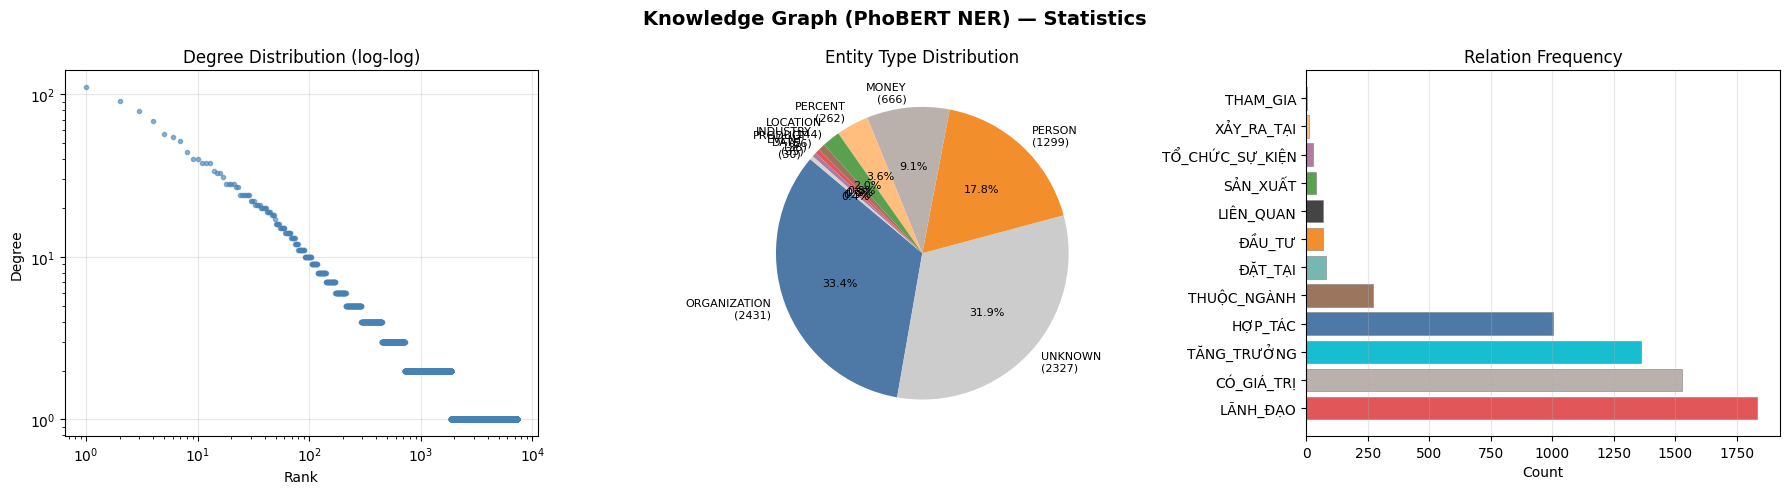

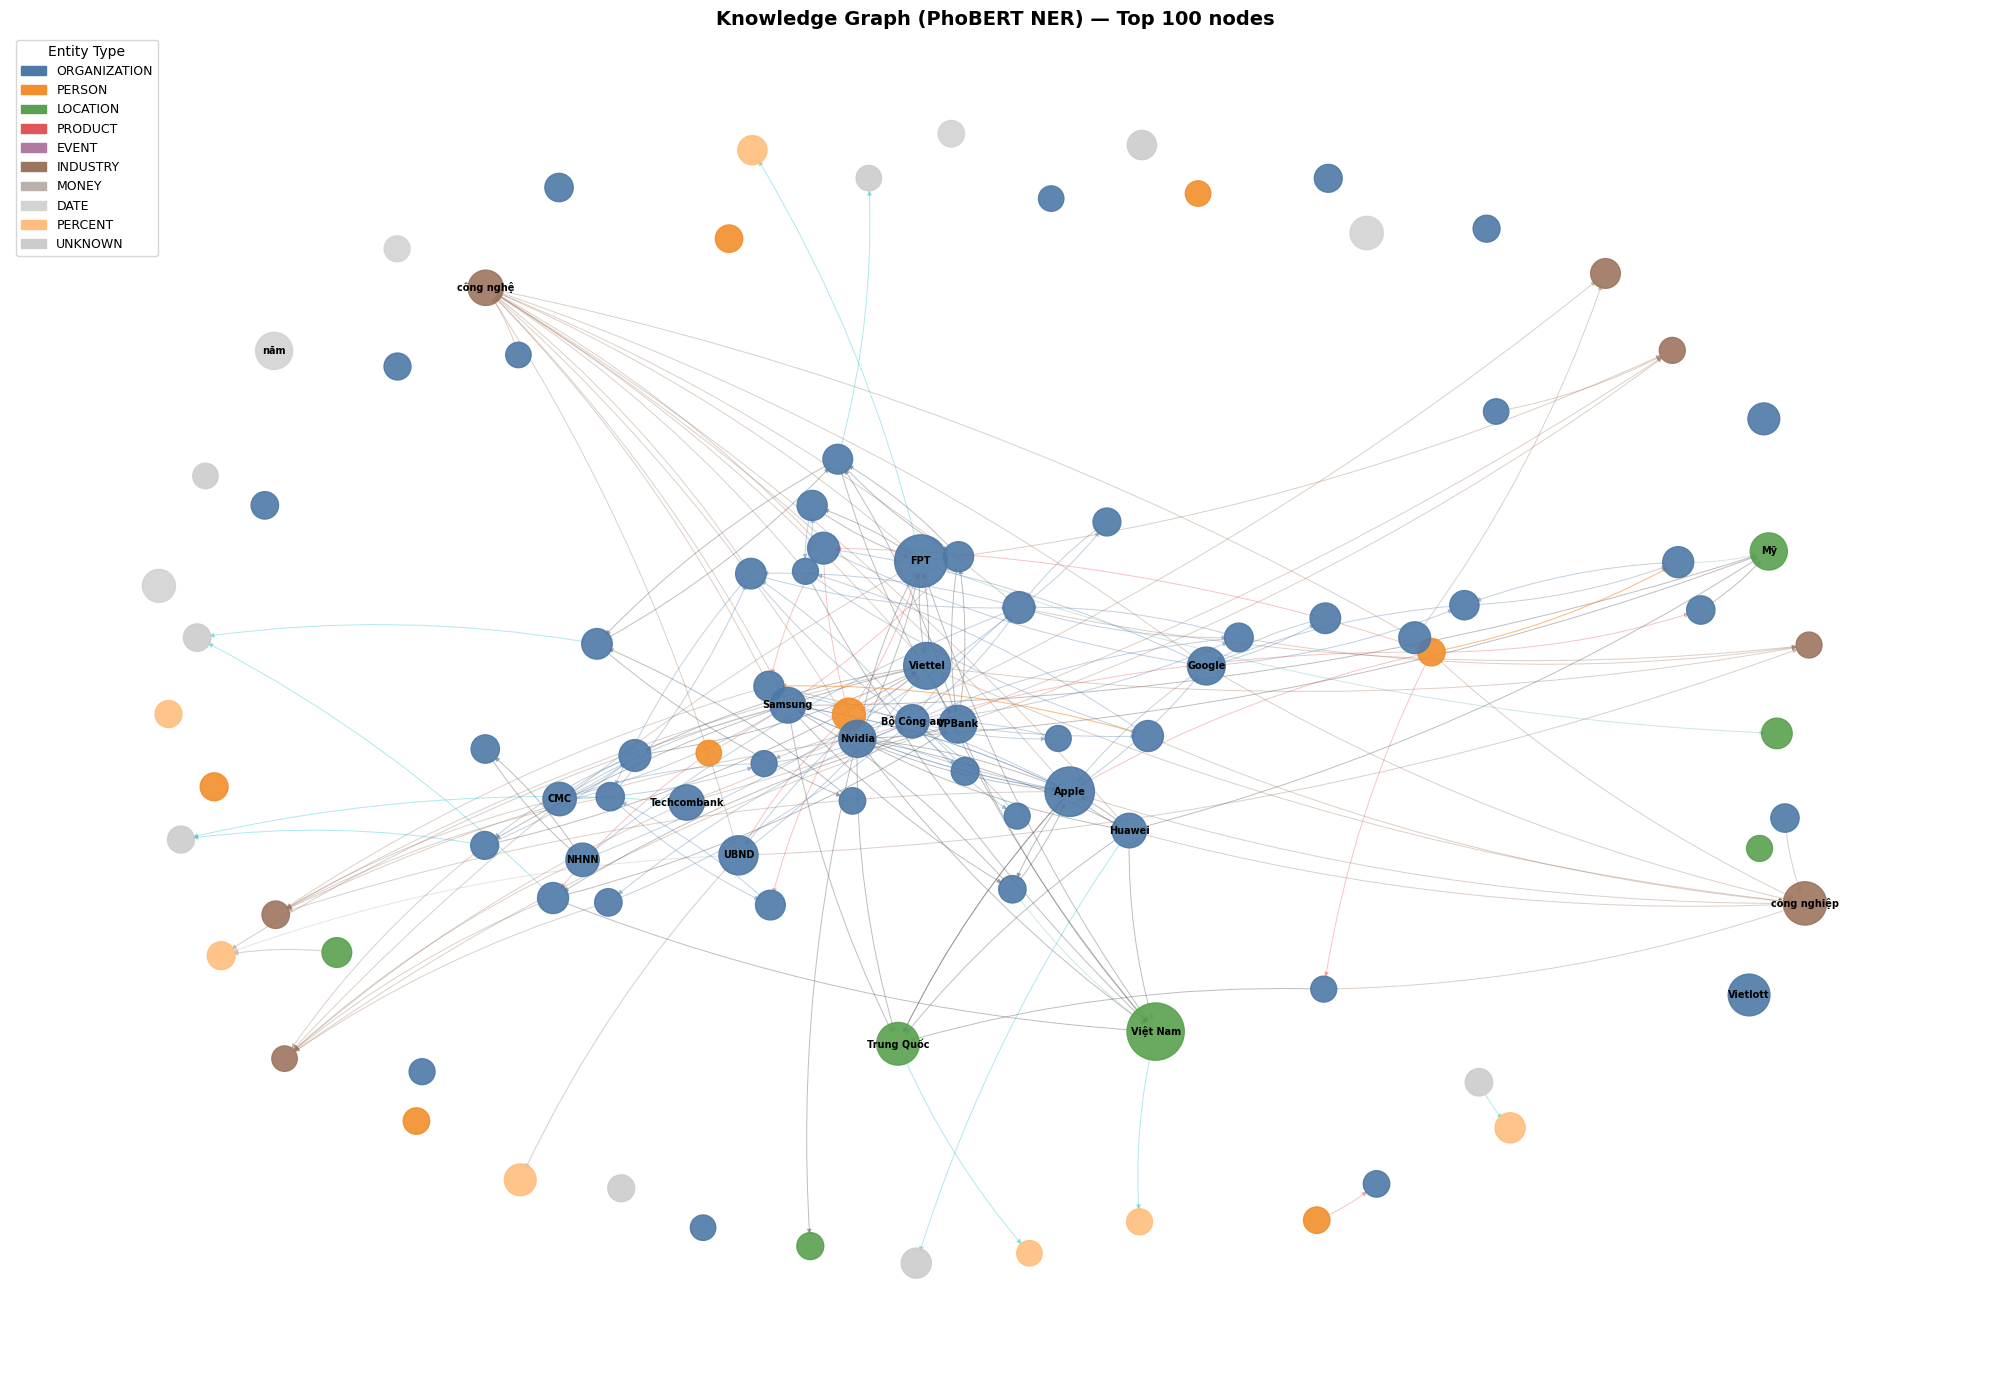

Saved: knowledge_graph_output/graph_statistics.png, graph_top_nodes.png


In [13]:
# ── Degree & Stats ────────────────────────────────────────────
in_deg  = dict(G.in_degree())
out_deg = dict(G.out_degree())
total_deg = {n: in_deg[n]+out_deg[n] for n in G.nodes()}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Knowledge Graph (PhoBERT NER) — Statistics', fontsize=14, fontweight='bold')

# Degree distribution
ax = axes[0]
deg_vals = sorted(total_deg.values(), reverse=True)
ax.loglog(range(1, len(deg_vals)+1), deg_vals, 'o', ms=3, color='steelblue', alpha=0.6)
ax.set_xlabel('Rank'); ax.set_ylabel('Degree'); ax.set_title('Degree Distribution (log-log)')
ax.grid(True, alpha=0.3)

# Entity type pie
ax = axes[1]
type_cnt = Counter(d.get('entity_type','?') for _,d in G.nodes(data=True))
labels_pie = [f"{k}\n({v})" for k, v in type_cnt.most_common()]
colors_pie = [ETYPE_COLOR.get(k,'#CCCCCC') for k, _ in type_cnt.most_common()]
ax.pie([v for _,v in type_cnt.most_common()], labels=labels_pie,
       colors=colors_pie, autopct='%1.1f%%', startangle=140,
       textprops={'fontsize':8})
ax.set_title('Entity Type Distribution')

# Relation bar
ax = axes[2]
rel_items = rel_dist.most_common()
ax.barh([r for r,_ in rel_items], [c for _,c in rel_items],
        color=[RELATION_COLOR.get(r,'#999') for r,_ in rel_items],
        edgecolor='gray', linewidth=0.4)
ax.set_xlabel('Count'); ax.set_title('Relation Frequency')
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT/'graph_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Top-K subgraph ────────────────────────────────────────────
top_k = CFG['top_k_viz']
top_nodes = {n for n,_ in sorted(total_deg.items(), key=lambda x:x[1], reverse=True)[:top_k]}
subG = G.subgraph(top_nodes)

fig, ax = plt.subplots(figsize=(20, 14))
ax.set_title(f'Knowledge Graph (PhoBERT NER) — Top {top_k} nodes', fontsize=14, fontweight='bold')

pos = nx.spring_layout(subG, k=2.5/np.sqrt(max(subG.number_of_nodes(),1)), seed=42, iterations=60)
max_deg = max(total_deg.values()) or 1
node_sizes  = [200 + 1500*(total_deg.get(n,1)/max_deg) for n in subG.nodes()]
node_colors = [G.nodes[n].get('color','#CCCCCC') for n in subG.nodes()]
edge_colors = [G[u][v][0].get('color','#AAAAAA') for u,v in subG.edges()]

nx.draw_networkx_edges(subG, pos, ax=ax, edge_color=edge_colors,
                       alpha=0.35, arrows=True, arrowsize=7, width=0.7,
                       connectionstyle='arc3,rad=0.08')
nx.draw_networkx_nodes(subG, pos, ax=ax, node_color=node_colors,
                       node_size=node_sizes, alpha=0.9)

top_labels = {n:n for n,_ in sorted(total_deg.items(),key=lambda x:x[1],reverse=True)[:CFG['top_k_labels']] if n in subG}
nx.draw_networkx_labels(subG, pos, labels=top_labels, ax=ax, font_size=7, font_weight='bold')

legend_patches = [mpatches.Patch(color=c, label=t) for t,c in ETYPE_COLOR.items() if t in type_cnt]
ax.legend(handles=legend_patches, loc='upper left', fontsize=9, title='Entity Type')
ax.axis('off')
plt.tight_layout()
plt.savefig(OUT/'graph_top_nodes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT}/graph_statistics.png, graph_top_nodes.png')

## 12. Interactive HTML (PyVis)

In [17]:
try:
    from pyvis.network import Network
    from IPython.display import display, HTML

    net = Network(height='750px', width='100%', directed=True,
                  notebook=True, cdn_resources='in_line')

    net.set_options("""
    {"physics":{"forceAtlas2Based":{"gravitationalConstant":-26,"centralGravity":0.005,
    "springLength":230,"springConstant":0.18},"maxVelocity":146,
    "solver":"forceAtlas2Based","timestep":0.35,
    "stabilization":{"iterations":150}},
    "edges":{"arrows":{"to":{"enabled":true}},
    "smooth":{"type":"curvedCW","roundness":0.1}},
    "interaction":{"hover":true,"multiselect":true}}
    """)

    # ── Nodes ─────────────────────────────────────────
    max_deg_v = max(total_deg.values()) if total_deg else 1

    for node in subG.nodes():
        etype = G.nodes[node].get('entity_type', 'UNKNOWN')
        color = G.nodes[node].get('color', '#CCCCCC')
        size  = 10 + 40 * (total_deg.get(node, 1) / max_deg_v)

        net.add_node(
            node,
            label=str(node),
            color=color,
            size=size,
            title=f'<b>{node}</b><br>Type: {etype}<br>Degree: {total_deg.get(node,0)}'
        )

    # ── Edges ─────────────────────────────────────────
    for u, v, data in subG.edges(data=True):
        ed = G[u][v][0] if G.has_edge(u, v) else {}

        relation   = str(ed.get('relation', ''))
        confidence = float(ed.get('confidence', 0))
        frequency  = int(ed.get('frequency', 1))
        color      = ed.get('color', '#AAAAAA')

        net.add_edge(
            u, v,
            label=relation,
            title=f"{relation} conf={confidence:.2f} freq={frequency}",
            color=color,
            width=max(1, float(np.log1p(frequency)))
        )

    # ── Save HTML (FIX Unicode) ───────────────────────
    html_path = OUT / 'knowledge_graph_interactive.html'

    html = net.generate_html()  # ⚠️ QUAN TRỌNG

    with open(html_path, 'w', encoding='utf-8') as f:
        f.write(html)

    print(f'✓ Interactive HTML: {html_path}')
    display(HTML(f'<a href="{html_path}" target="_blank">🔗 Mở Knowledge Graph Interactive</a>'))

except ImportError:
    print('pyvis chưa cài — pip install pyvis')

✓ Interactive HTML: knowledge_graph_output\knowledge_graph_interactive.html


## 13. Quality Check & Sample Triples

In [18]:
import random
random.seed(42)

rel_groups = defaultdict(list)
for t in triples_final:
    rel_groups[t.relation].append(t)

print('='*65)
print('SAMPLE TRIPLES BY RELATION TYPE')
print('='*65)
for relation, group in sorted(rel_groups.items()):
    samples = random.sample(group, min(3, len(group)))
    print(f'\n── {relation} ({len(group):,} triples) ──')
    for t in samples:
        print(f'  [{t.subject_type:12s}] "{t.subject}"')
        print(f'   ──{t.relation}──→  (conf={t.confidence:.2f})')
        print(f'  [{t.obj_type:12s}] "{t.obj}"')
        print(f'  Source: "{t.source_text[:80]}"')
        print()

print('='*65)
print('FINAL SUMMARY')
print('='*65)
print(f'NER model            : {CFG["model_dir"]}')
print(f'Input rows           : {len(df):,}')
print(f'Sentences processed  : {len(sentence_records):,}')
print(f'Triples (final)      : {len(triples_final):,}')
print(f'Graph nodes          : {G.number_of_nodes():,}')
print(f'Graph edges          : {G.number_of_edges():,}')
print(f'Relation types       : {len(rel_groups)}')
print(f'Entity types         : {len(type_cnt)}')
print(f'Output dir           : {OUT.resolve()}')

SAMPLE TRIPLES BY RELATION TYPE

── CÓ_GIÁ_TRỊ (1,528 triples) ──
  [LOCATION    ] "Việt Nam"
   ──CÓ_GIÁ_TRỊ──→  (conf=0.75)
  [MONEY       ] "930 tỷ"
  Source: "Thích ứng linh hoạt, xuất nhập khẩu lập kỷ lục Kết thúc năm 2025, kim ngạch xuất"

  [UNKNOWN     ] "Vẫn còn 30 lon vàng"
   ──CÓ_GIÁ_TRỊ──→  (conf=0.75)
  [UNKNOWN     ] "50 triệu đồng"
  Source: "Hành trình săn lon vàng Tiger sẽ khép lại vào ngày 13/8 - đánh dấu cơ hội cuối c"

  [UNKNOWN     ] "Huy động từ Khách hàng và phát hành giấy tờ có giá"
   ──CÓ_GIÁ_TRỊ──→  (conf=0.75)
  [UNKNOWN     ] "149.587 tỷ đồng"
  Source: "Cụ thể, tính đến hết ngày 30/6/2025, quy mô hoạt động của ABBank ghi nhận sự tăn"


── HỢP_TÁC (1,002 triples) ──
  [ORGANIZATION] "Nexon"
   ──HỢP_TÁC──→  (conf=0.80)
  [ORGANIZATION] "Samsung"
  Source: "Thông qua quan hệ hợp tác, các nhà phát triển game có thể kiểm soát hiệu ứng 3D "

  [ORGANIZATION] "Toho Gas"
   ──HỢP_TÁC──→  (conf=0.80)
  [ORGANIZATION] "Hướng Việt Holding"
  Source: "Sẵn sàng đón 

## 14. Inference trên bài báo mới (Real-time Update)

Cell này demo khả năng **cập nhật KG theo thời gian thực** với bài báo mới — không cần chạy lại toàn bộ pipeline.

In [19]:
def process_new_article(title: str, content: str, article_id: int = -1) -> List[Triple]:
    """
    Xử lý 1 bài báo mới → extract triples → (tuỳ chọn) thêm vào Graph G.

    Quy trình:
    1. Normalize text
    2. Split thành câu
    3. PhoBERT NER inference (batch)
    4. Normalize entities
    5. Extract triples
    Returns: list of Triple (chưa add vào G — caller quyết định)
    """
    new_triples: List[Triple] = []

    for field_text in (title, content):
        text = normalize_text(str(field_text or ''))
        if not text.strip():
            continue

        sents = split_sentences(text, CFG['max_sent_chars'])
        if not sents:
            continue

        # Batch NER
        try:
            batch_res = ner_pipe(sents)
            if sents and not isinstance(batch_res[0], list):
                batch_res = [batch_res]
        except Exception:
            batch_res = [[] for _ in sents]

        for sent, ner_list in zip(sents, batch_res):
            entities = [
                EntitySpan(
                    text  = normalize_entity(e['word'].strip(), e['entity_group']),
                    etype = e['entity_group'],
                    score = e['score'],
                )
                for e in ner_list
                if e['score'] >= CFG['min_ner_score'] and normalize_entity(e['word'].strip())
            ]
            if not entities:
                continue
            rec = SentenceRecord(row_id=article_id, text=sent, entities=entities)
            new_triples.extend(extract_triples_from_record(rec))

    return new_triples


def add_triples_to_graph(new_triples: List[Triple], graph: nx.MultiDiGraph) -> int:
    """Thêm triples mới vào graph G. Returns: số edge mới thêm."""
    added = 0
    for t in new_triples:
        for name, etype in [(t.subject, t.subject_type), (t.obj, t.obj_type)]:
            if name not in graph:
                graph.add_node(name, entity_type=etype,
                               color=ETYPE_COLOR.get(etype,'#CCCCCC'))
        graph.add_edge(t.subject, t.obj,
                       relation=t.relation, confidence=t.confidence,
                       frequency=1, weight=t.confidence,
                       source_id=t.source_id)
        added += 1
    return added


# ── Demo ─────────────────────────────────────────────────────
new_title   = 'Vietcombank và BIDV ký kết hợp tác toàn diện tại Hà Nội năm 2025'
new_content = (
    'Ngày 15/3/2025, Chủ tịch Vietcombank ông Nguyễn Thanh Tùng '
    'và Tổng giám đốc BIDV ông Lê Ngọc Lâm đã ký biên bản ghi nhớ '
    'hợp tác chiến lược trị giá 500 tỷ đồng tại TP.HCM. '
    'Hai ngân hàng sẽ phối hợp trong lĩnh vực ngân hàng số và công nghệ tài chính.'
)

print('Demo: xử lý bài báo mới...')
t0 = time.time()
new_triples = process_new_article(new_title, new_content, article_id=99999)
print(f'Inference time: {time.time()-t0:.2f}s')
print(f'Triples found : {len(new_triples)}')

for t in new_triples:
    print(f'  [{t.subject_type:12s}] "{t.subject}"  ──{t.relation}──→  '
          f'[{t.obj_type:12s}] "{t.obj}"  (conf={t.confidence:.2f})')

# Thêm vào graph
added = add_triples_to_graph(new_triples, G)
print(f'\nGraph sau update: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges (+{added} edges)')

Demo: xử lý bài báo mới...
Inference time: 0.12s
Triples found : 6
  [ORGANIZATION] "Vietcombank"  ──LIÊN_QUAN──→  [ORGANIZATION] "BIDV"  (conf=0.50)
  [ORGANIZATION] "BIDV"  ──LIÊN_QUAN──→  [ORGANIZATION] "Vietcombank"  (conf=0.50)
  [ORGANIZATION] "Vietcombank"  ──LIÊN_QUAN──→  [LOCATION    ] "Hà Nội"  (conf=0.50)
  [ORGANIZATION] "BIDV"  ──LIÊN_QUAN──→  [LOCATION    ] "Hà Nội"  (conf=0.50)
  [PERSON      ] "Nguyễn Thanh Tùng"  ──LÃNH_ĐẠO──→  [ORGANIZATION] "BIDV"  (conf=0.85)
  [UNKNOWN     ] "Ngọc Lâm đã ký biên bản ghi nhớ hợp tác chiến lược"  ──CÓ_GIÁ_TRỊ──→  [UNKNOWN     ] "500 tỷ đồng"  (conf=0.75)

Graph sau update: 7,289 nodes, 6,304 edges (+6 edges)


## 15. Tổng kết

### Pipeline

| Bước | Module | Output |
|------|--------|--------|
| Text normalization | Unicode NFC + regex | Clean text |
| Sentence splitting | Regex + chunking | `List[str]` ≤600 chars |
| **PhoBERT NER** | `phobert-ner-final` (fine-tuned) | `List[EntitySpan]` |
| Entity normalization | Alias map + length filter | Canonical entity names |
| Relation extraction | 11 Vietnamese regex patterns | `List[Triple]` |
| Co-occurrence fallback | Short sentence heuristic | `LIÊN_QUAN` triples |
| Filtering | Confidence + noise + dedup | Final triples |
| Graph build | NetworkX MultiDiGraph | `G` |
| Export | CSV / JSON / GraphML / GEXF / HTML | 5 files |

### Ưu điểm so với đọc CSV

- **Chất lượng cao hơn**: PhoBERT fine-tuned trên đúng domain doanh nghiệp Việt Nam
- **Confidence-aware**: NER score của entity được tích hợp vào triple confidence
- **Real-time ready**: `process_new_article()` xử lý bài mới trong < 1 giây (GPU)
- **Không phụ thuộc file label**: Chỉ cần raw text + model

### Output cho bước tiếp theo

| File | Bước |
|------|------|
| `triples.csv` | Bước 4 (Graph Analysis), Power BI |
| `triples.json` | KG Explorer web app |
| `knowledge_graph.graphml` | **Bước 4** (NetworkX input) |
| `knowledge_graph.gexf` | Gephi visualization |